<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/Random_Forest_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/glass")

print("Path to dataset files:", path)

100%|██████████| 3.42k/3.42k [00:00<00:00, 4.57MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/glass/versions/1


In [4]:
import os
os.listdir(path='/root/.cache/kagglehub/datasets/uciml/glass/versions/1')

['glass.csv']

In [5]:
import pandas as pd
df = pd.read_csv('/root/.cache/kagglehub/datasets/uciml/glass/versions/1/glass.csv')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [7]:
df.corr()['Type']

,Type
RI,-0.164237
Na,0.502898
Mg,-0.744993
Al,0.598829
Si,0.151565
K,-0.010054
Ca,0.000952
Ba,0.575161
Fe,-0.188278
Type,1.000000


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [9]:
X = df.drop('Type', axis=1)
y = df['Type']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=3, random_state=42)

In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.813953488372093


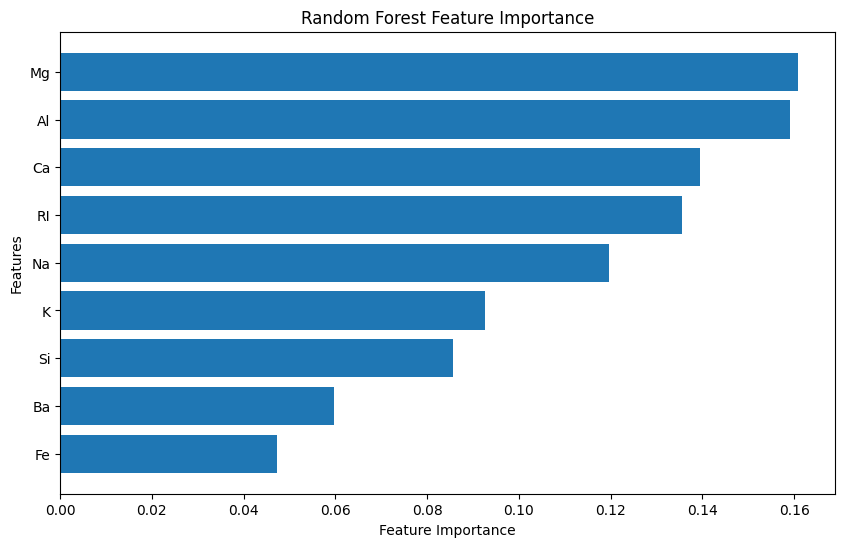

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort values
importance = importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance.index, importance.values)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
classification = classification_report(y_test, y_pred)
print(classification)

              precision    recall  f1-score   support

           1       0.71      0.91      0.80        11
           2       0.77      0.71      0.74        14
           3       1.00      0.67      0.80         3
           5       1.00      0.50      0.67         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.81        43
   macro avg       0.90      0.80      0.82        43
weighted avg       0.83      0.81      0.81        43



In [33]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9941520467836257
Testing Accuracy : 0.813953488372093


In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Average:", scores.mean())

[0.74418605 0.69767442 0.65116279 0.55813953 0.71428571]
Average: 0.6730897009966779
